# Credit Score Classification — Data Exploration & Modeling

**Alur notebook:**
`Load → Train/Test Split → Preprocessing inti → EDA → Preprocessing lanjutan →
Feature Engineering → Encoding → Modeling (10 model, tanpa tuning) → Top-3 →
Hyperparameter Tuning (GridSearch + class_weight) → Feature Importance`

## 1. Setup & Load Data

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from itertools import product
from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV,
                                     cross_val_predict)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("data_C.csv")
print("Shape:", df.shape)
df.head()

Shape: (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,8,32,3,"Personal Loan, Student Loan, and Mortgage Loan",23,9,10.3,11.0,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,9,10,1663,2,"Personal Loan, and Student Loan",58,14,15.53,6.0,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,1,6,2,1,Auto Loan,25,4,5.04,1.0,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,3,7,5,0,NaN,30,15,24.73,6.0,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,4,1405,14,6,"Auto Loan, Payday Loan, Student Loan, Auto Loa...",30,19,16.44,7.0,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22570 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21164 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null  object 
 14  Type_o

### 1.1 Distribusi Target & Pemeriksaan Cepat Kualitas Data

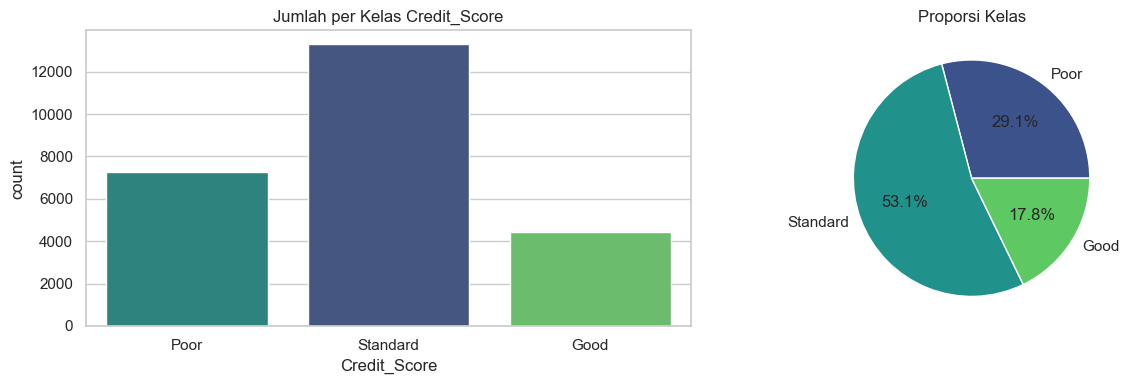

Credit_Score
Standard    53.13
Poor        29.07
Good        17.80
Name: proportion, dtype: float64


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
order = ["Poor", "Standard", "Good"]
sns.countplot(x="Credit_Score", data=df, order=order, hue="Credit_Score",
              palette="viridis", legend=False, ax=ax[0])
ax[0].set_title("Jumlah per Kelas Credit_Score")
df["Credit_Score"].value_counts().reindex(order).plot.pie(
    autopct="%1.1f%%", ax=ax[1], ylabel="", colors=sns.color_palette("viridis", 3))
ax[1].set_title("Proporsi Kelas")
plt.tight_layout(); plt.show()
print((df["Credit_Score"].value_counts(normalize=True) * 100).round(2))

**Target imbalanced** (`Standard`~53%, `Poor`~29%, `Good`~18%). Implikasi:
- Metrik utama = **Macro-F1** (adil untuk minoritas), bukan accuracy.
- Tangani imbalance via **`class_weight='balanced'`** saat training.

In [5]:
# Identifikasi masalah kualitas data (cardinality, missing, placeholder tersembunyi)
quality = pd.DataFrame({"n_unique": df.nunique(), "dtype": df.dtypes,
                        "n_missing": df.isna().sum()})
print(quality)
print("\nContoh placeholder tersembunyi (hidden missing):")
for c, v in [("Occupation", "_______"), ("Credit_Mix", "_"),
             ("Payment_Behaviour", "!@9#%8"), ("Payment_of_Min_Amount", "NM")]:
    print(f"  {c:<22} '{v}' : {(df[c] == v).sum()}")

                          n_unique    dtype  n_missing
Unnamed: 0                   25000    int64          0
ID                           25000   object          0
Customer_ID                  11254   object          0
Month                            8   object          0
Name                          8995   object       2430
Age                            551   object          0
SSN                          11061   object          0
Occupation                      16   object          0
Annual_Income                12845   object          0
Monthly_Inhand_Salary        10830  float64       3836
Num_Bank_Accounts              343    int64          0
Num_Credit_Card                489    int64          0
Interest_Rate                  545    int64          0
Num_of_Loan                    150   object          0
Type_of_Loan                  5731   object       2852
Delay_from_due_date             73    int64          0
Num_of_Delayed_Payment         235   object       1792
Changed_Cr

**Temuan kualitas data:**
1. Kolom identitas (`Unnamed: 0`, `ID`, `Customer_ID`, `Name`, `SSN`) → non-informatif, **drop**.
2. Numerik kotor (`28_`, `__10000__`) tersimpan sebagai teks → perlu parsing.
3. *Hidden missing* (`_______`, `_`, `!@9#%8`, `NM`) → perlu dinormalisasi jadi NaN/Unknown.
4. `Credit_History_Age` berupa teks `"X Years and Y Months"` → konversi ke bulan.
5. Fitur majemuk: `Payment_Behaviour` & `Type_of_Loan` → perlu didekomposisi.

## 2. Train / Test Split (dilakukan paling awal)

Split dilakukan **sebelum** preprocessing apa pun yang memerlukan statistik (imputasi, capping,
encoder, scaler). Semua parameter transformasi **di-fit hanya pada data train**, lalu diterapkan
ke tes, ini mencegah *data leakage*. `stratify=y` menjaga proporsi kelas di train & test.

In [6]:
X = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (20000, 28) | Test: (5000, 28)


## 3. Preprocessing Inti (paling penting)

Mencakup transformasi *per-baris* yang deterministik (drop identifier, parsing numerik, validasi
domain, konversi teks), diterapkan ke train & test lewat fungsi yang sama. Statistik (median
imputasi, batas outlier) **di-fit di train**.

In [7]:
import re

def core_clean(data: pd.DataFrame) -> pd.DataFrame:
    """Transformasi per-baris (deterministik): aman untuk train & test."""
    data = data.copy()
    # (a) Drop kolom identitas & indeks
    data = data.drop(columns=["Unnamed: 0", "ID", "Customer_ID", "Name", "SSN"], errors="ignore")
    # (b) Parsing numerik kotor -> float
    for col in ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment",
                "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly",
                "Monthly_Balance"]:
        data[col] = pd.to_numeric(
            data[col].astype(str).str.replace(r"[^0-9.\-]", "", regex=True).replace("", np.nan),
            errors="coerce")
    # (c) Validasi domain -> nilai mustahil jadi NaN
    data["Age"] = data["Age"].where(data["Age"].between(18, 100), np.nan)
    data["Monthly_Balance"] = data["Monthly_Balance"].where(data["Monthly_Balance"] >= 0, np.nan)
    # (d) Count negatif -> 0
    for col in ["Num_of_Loan", "Num_Bank_Accounts", "Num_of_Delayed_Payment",
                "Delay_from_due_date", "Num_Credit_Card", "Num_Credit_Inquiries"]:
        data[col] = pd.to_numeric(data[col], errors="coerce").clip(lower=0)
    # (e) Credit_History_Age teks -> total bulan
    def to_months(x):
        if pd.isna(x):
            return np.nan
        m = re.match(r"(\d+)\s*Years?\s*and\s*(\d+)\s*Months?", str(x))
        return int(m.group(1)) * 12 + int(m.group(2)) if m else np.nan
    data["Credit_History_Age"] = data["Credit_History_Age"].apply(to_months)
    # (f) Normalisasi placeholder kategorikal
    data["Occupation"] = data["Occupation"].replace("_______", "Unknown")
    data["Credit_Mix"] = data["Credit_Mix"].replace("_", "Unknown")
    data["Payment_of_Min_Amount"] = data["Payment_of_Min_Amount"].replace("NM", "Unknown")
    data["Payment_Behaviour"] = data["Payment_Behaviour"].replace("!@9#%8", np.nan)
    data["Type_of_Loan"] = data["Type_of_Loan"].fillna("Not Specified")
    return data

X_train = core_clean(X_train)
X_test = core_clean(X_test)
print("Shape setelah core_clean:", X_train.shape)

Shape setelah core_clean: (20000, 23)


### 3.1 Imputasi Missing Value (median/Unknown, fit di train)

In [8]:
miss = (X_train.isna().mean() * 100).round(2)
print("Missing (%) > 0 di train:")
print(miss[miss > 0].sort_values(ascending=False))

Missing (%) > 0 di train:
Monthly_Inhand_Salary      15.34
Credit_History_Age          8.70
Age                         8.66
Payment_Behaviour           7.75
Num_of_Delayed_Payment      7.13
Amount_invested_monthly     4.61
Changed_Credit_Limit        2.07
Num_Credit_Inquiries        1.89
Monthly_Balance             1.23
dtype: float64


In [9]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

num_impute = {c: X_train[c].median() for c in num_cols}   # fit di train
X_train[num_cols] = X_train[num_cols].fillna(num_impute)
X_test[num_cols] = X_test[num_cols].fillna(num_impute)
X_train[cat_cols] = X_train[cat_cols].fillna("Unknown")
X_test[cat_cols] = X_test[cat_cols].fillna("Unknown")
print("Sisa missing -> train:", int(X_train.isna().sum().sum()), "| test:", int(X_test.isna().sum().sum()))

Sisa missing -> train: 0 | test: 0


### 3.2 Outlier Capping (IQR untuk count, P99 untuk moneter, fit di train)

In [10]:
iqr_cols = ["Num_Bank_Accounts", "Num_Credit_Card", "Num_of_Loan", "Num_of_Delayed_Payment",
            "Num_Credit_Inquiries", "Delay_from_due_date", "Interest_Rate"]
p99_cols = ["Annual_Income", "Monthly_Inhand_Salary", "Outstanding_Debt",
            "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"]

caps = {}
for col in iqr_cols:
    q1, q3 = X_train[col].quantile([0.25, 0.75]); iqr = q3 - q1
    caps[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
for col in p99_cols:
    caps[col] = (X_train[col].min(), X_train[col].quantile(0.99))
for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)
print("Outlier capping diterapkan ke", len(caps), "kolom (batas dari train).")

Outlier capping diterapkan ke

 13 kolom (batas dari train).


## 4. Exploratory Data Analysis (pada train yang sudah bersih)

EDA dilakukan **hanya pada train** agar tidak mengintip test set. (8 visualisasi)

In [11]:
eda = X_train.copy(); eda["Credit_Score"] = y_train.values

### Plot 1 — Heatmap Korelasi Fitur Numerik

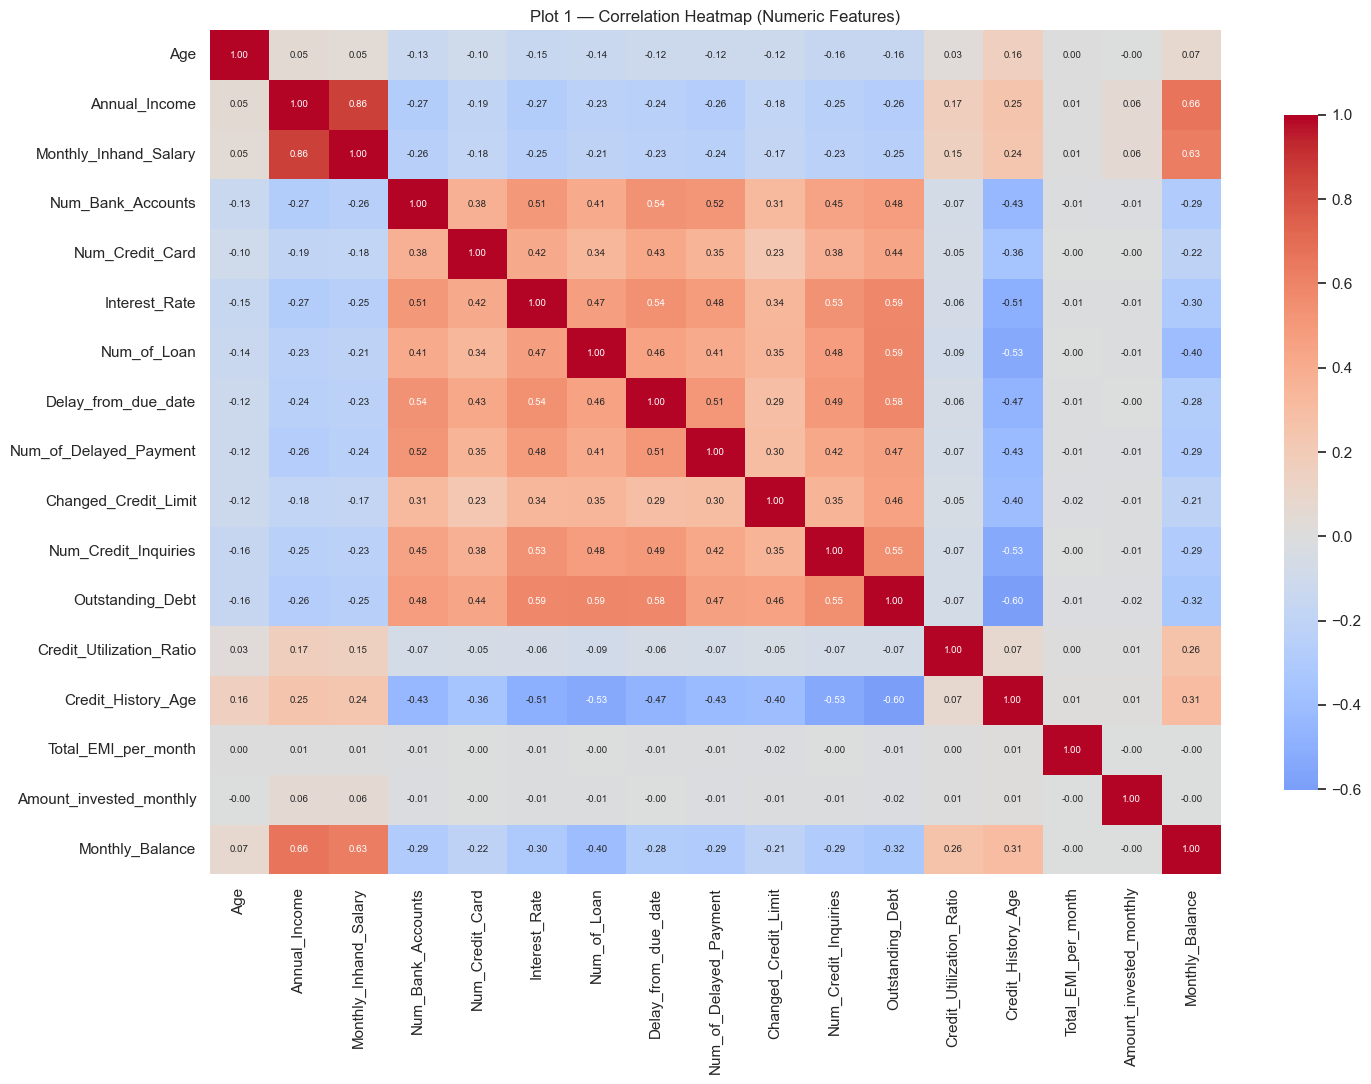

In [12]:
plt.figure(figsize=(15, 11))
sns.heatmap(eda.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, annot_kws={"size": 7}, cbar_kws={"shrink": .8})
plt.title("Plot 1 — Correlation Heatmap (Numeric Features)")
plt.tight_layout(); plt.show()

**Insight:** Fitur-fitur risiko (`Outstanding_Debt`, `Delay_from_due_date`, `Interest_Rate`) menunjukkan korelasi positif satu sama lain, sementara `Annual_Income` dan `Monthly_Inhand_Salary` berkorelasi sangat kuat (>0.9) dan bersifat redundan — kondisi ini menjadi dasar pembuatan fitur rasio seperti `Debt_to_Income` yang lebih informatif, dan tidak bermasalah untuk model tree-based.

### Plot 2 — Boxplot Fitur Risiko Kunci vs Credit_Score

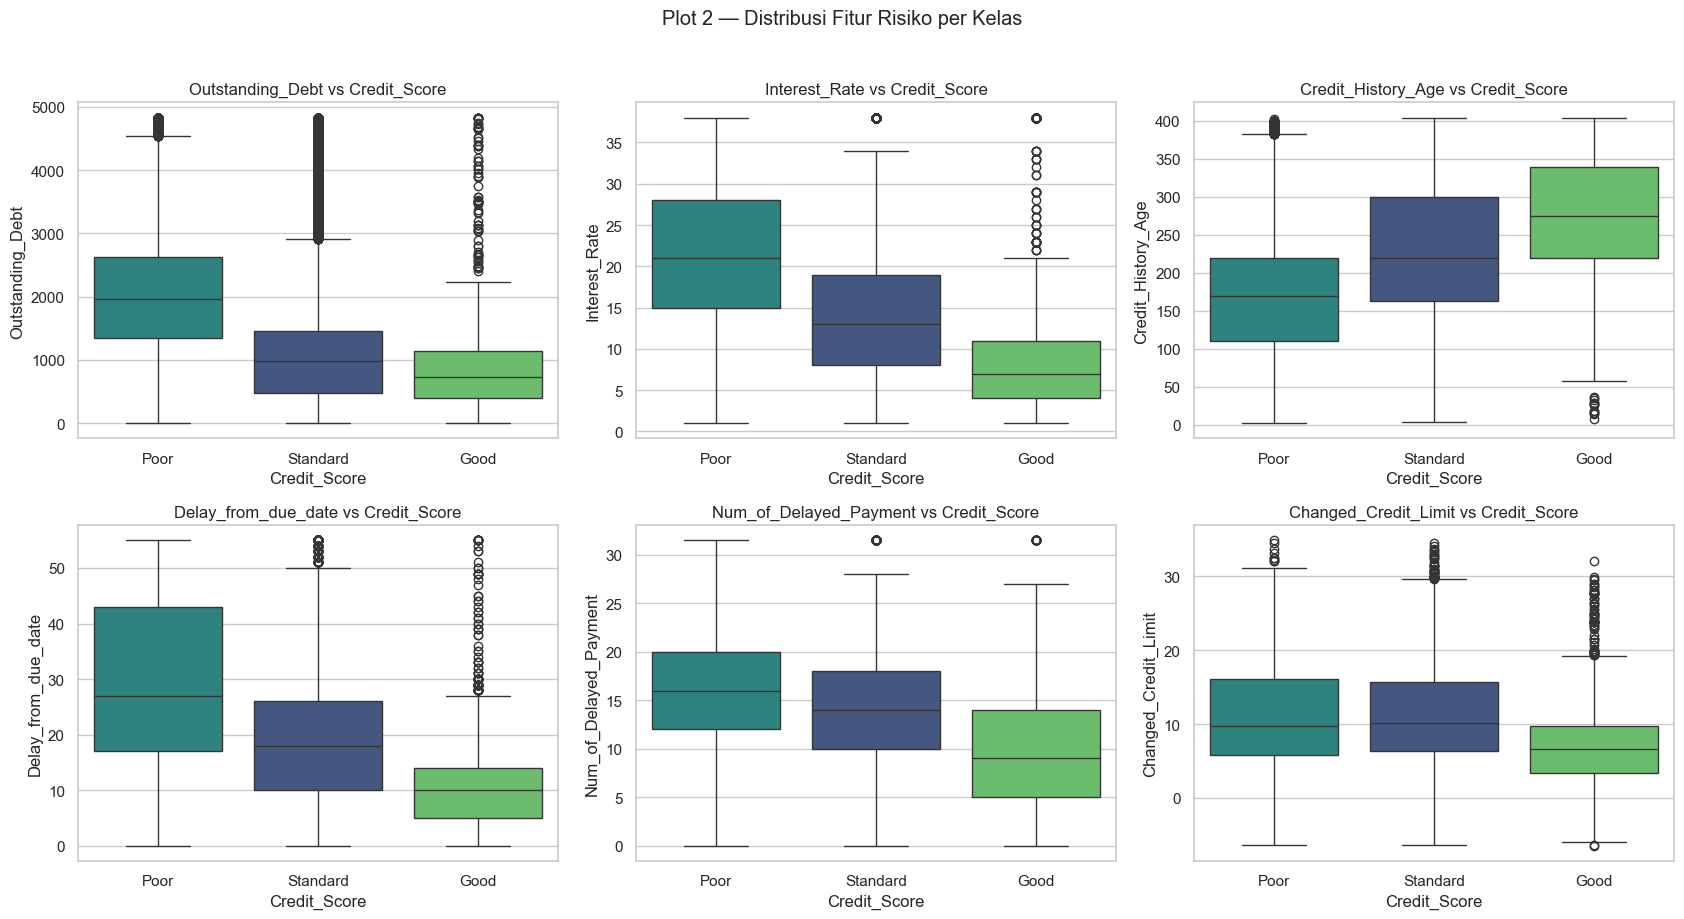

In [13]:
key_num = ["Outstanding_Debt", "Interest_Rate", "Credit_History_Age",
           "Delay_from_due_date", "Num_of_Delayed_Payment", "Changed_Credit_Limit"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), key_num):
    sns.boxplot(x="Credit_Score", y=col, data=eda, order=order, hue="Credit_Score",
                palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{col} vs Credit_Score")
plt.suptitle("Plot 2 — Distribusi Fitur Risiko per Kelas", y=1.02)
plt.tight_layout(); plt.show()

**Insight:** `Poor` cenderung punya utang, bunga, & keterlambatan lebih tinggi serta histori
kredit lebih pendek dibanding `Good` — fitur-fitur ini diharapkan sangat prediktif.

### Plot 3 — Boxplot Annual_Income vs Credit_Score

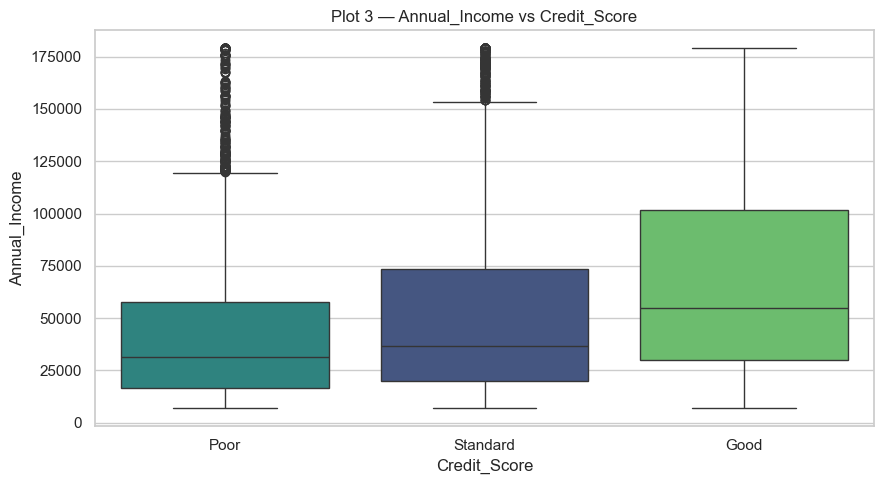

In [14]:
plt.figure(figsize=(9, 5))
sns.boxplot(x="Credit_Score", y="Annual_Income", data=eda, order=order, hue="Credit_Score",
            palette="viridis", legend=False)
plt.title("Plot 3 — Annual_Income vs Credit_Score"); plt.tight_layout(); plt.show()

**Insight:** Nasabah kelas `Good` cenderung memiliki `Annual_Income` sedikit lebih tinggi, namun distribusi ketiga kelas sangat tumpang tindih — pendapatan absolut bukan pembeda yang kuat, sehingga fitur rasio seperti `Debt_to_Income` dan `EMI_to_Salary` diperlukan untuk menangkap kemampuan bayar secara relatif.

### Plot 4 — Komposisi Credit_Score per Kategori (Credit_Mix, Payment_of_Min, Spending)

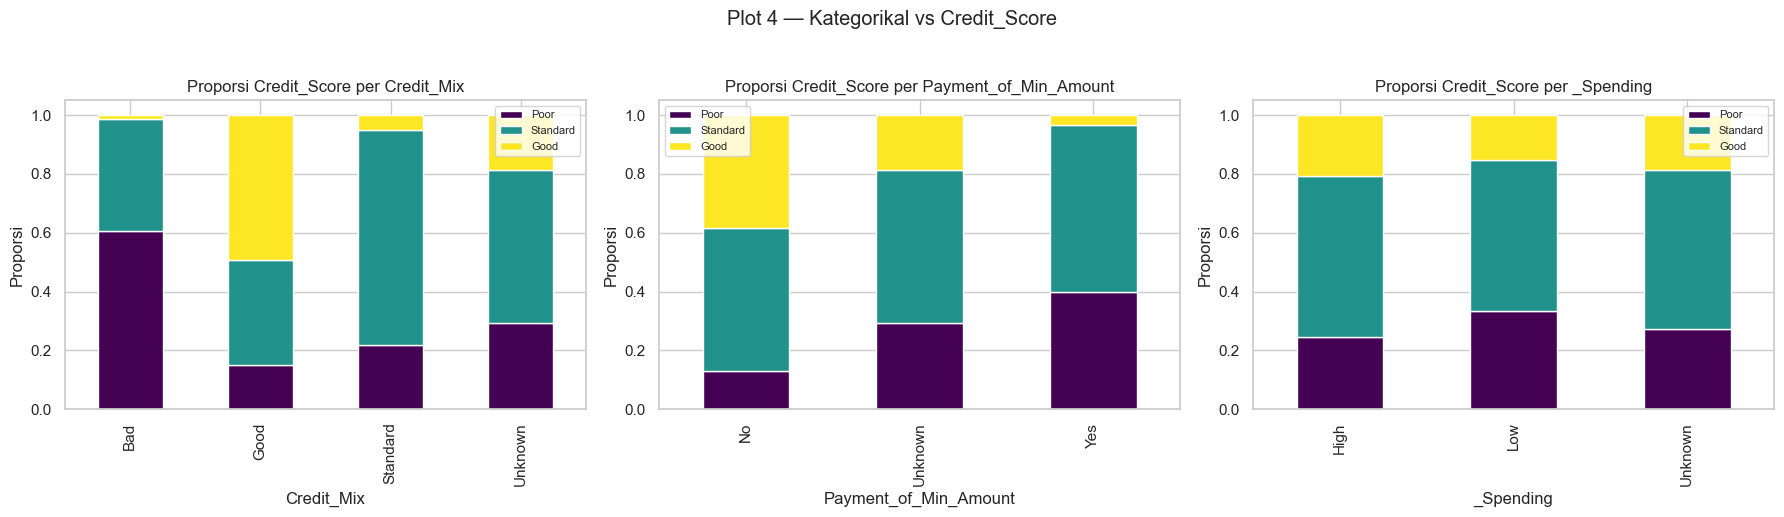

In [15]:
# Spending_Level sementara (untuk EDA) — dekomposisi formal di Bagian 5
eda["_Spending"] = eda["Payment_Behaviour"].str.extract(r"(Low|High)_spent").fillna("Unknown")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["Credit_Mix", "Payment_of_Min_Amount", "_Spending"]):
    (pd.crosstab(eda[col], eda["Credit_Score"], normalize="index")[order]
     .plot(kind="bar", stacked=True, ax=ax, colormap="viridis"))
    ax.set_title(f"Proporsi Credit_Score per {col}"); ax.set_ylabel("Proporsi")
    ax.legend(fontsize=8)
plt.suptitle("Plot 4 — Kategorikal vs Credit_Score", y=1.03)
plt.tight_layout(); plt.show()

**Insight:** `Credit_Mix` sangat diskriminatif & jelas **ordinal** (Bad→Poor, Good→Good) →
mendukung keputusan encoding ordinal.

### Plot 5 — Distribusi (Histogram) Beberapa Fitur Numerik

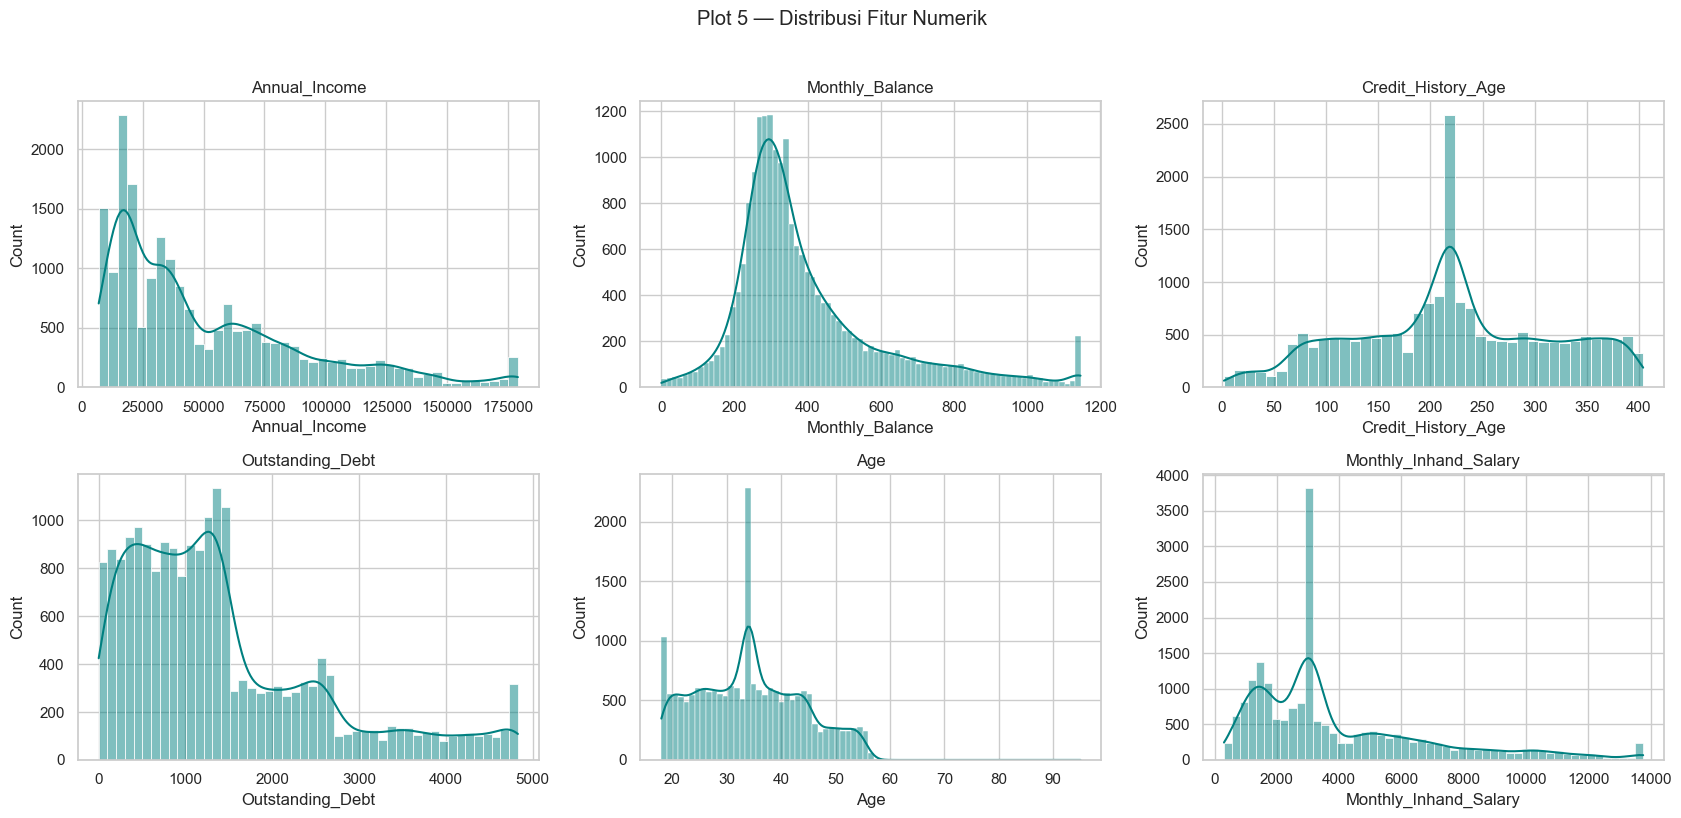

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, col in zip(axes.ravel(), ["Annual_Income", "Monthly_Balance", "Credit_History_Age",
                                   "Outstanding_Debt", "Age", "Monthly_Inhand_Salary"]):
    sns.histplot(eda[col], kde=True, ax=ax, color="teal")
    ax.set_title(col)
plt.suptitle("Plot 5 — Distribusi Fitur Numerik", y=1.02)
plt.tight_layout(); plt.show()

**Insight:** Mayoritas fitur numerik (terutama `Annual_Income`, `Outstanding_Debt`, `Monthly_Balance`) berdistribusi **right-skewed** dengan ekor panjang ke kanan — mengkonfirmasi perlunya outlier capping (IQR/P99) yang telah dilakukan, sekaligus menunjukkan bahwa model tree-based lebih cocok karena tidak mengasumsikan distribusi normal.

### Plot 6 — Scatter: Outstanding_Debt vs Credit_Utilization_Ratio

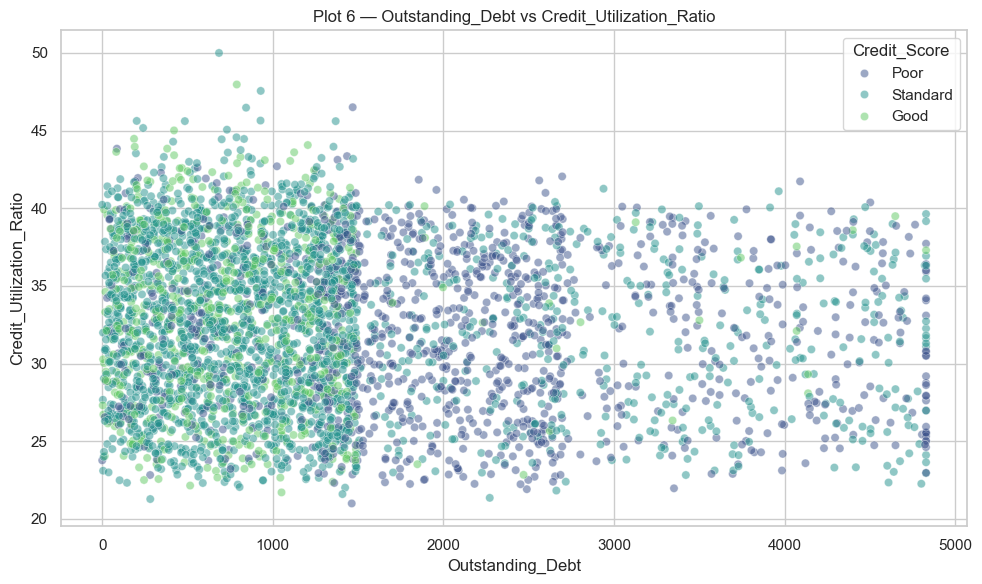

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Outstanding_Debt", y="Credit_Utilization_Ratio", hue="Credit_Score",
                hue_order=order, data=eda.sample(4000, random_state=RANDOM_STATE),
                alpha=0.5, palette="viridis")
plt.title("Plot 6 — Outstanding_Debt vs Credit_Utilization_Ratio"); plt.tight_layout(); plt.show()

**Insight:** Ketiga kelas tersebar bercampur tanpa batas linier yang jelas antara `Outstanding_Debt` dan `Credit_Utilization_Ratio` — pemisahan kelas membutuhkan kombinasi **non-linier** dari banyak fitur sekaligus, yang mendukung penggunaan model tree-based dibanding model linear.

### Plot 7 — Rata-rata Fitur Risiko per Kelas (Barplot)

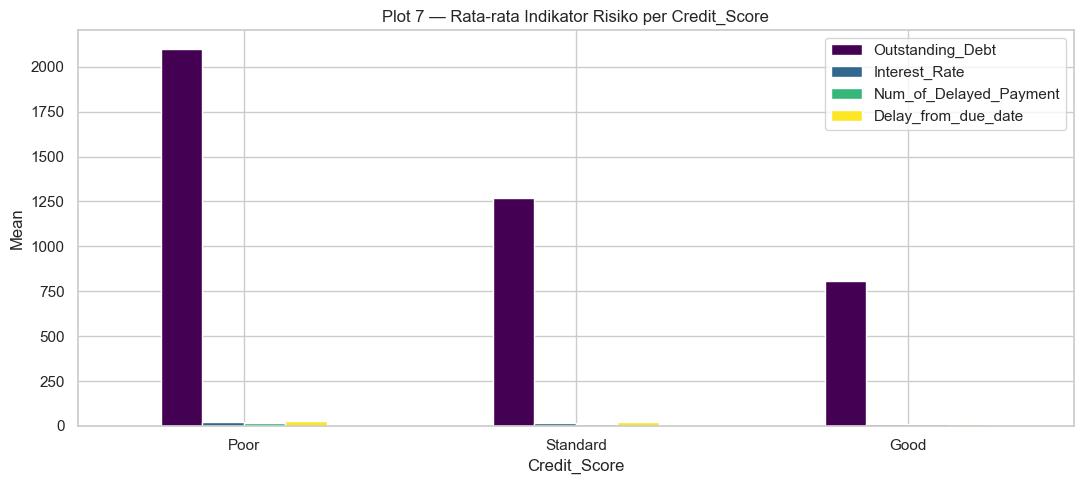

In [18]:
agg = eda.groupby("Credit_Score")[["Outstanding_Debt", "Interest_Rate",
                                    "Num_of_Delayed_Payment", "Delay_from_due_date"]].mean().reindex(order)
agg.plot(kind="bar", figsize=(11, 5), colormap="viridis")
plt.title("Plot 7 — Rata-rata Indikator Risiko per Credit_Score")
plt.ylabel("Mean"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Insight:** Semua indikator risiko meningkat secara konsisten dari kelas `Good` → `Standard` → `Poor`, dengan perbedaan paling mencolok pada `Outstanding_Debt` dan `Delay_from_due_date` — pola monoton ini mengonfirmasi bahwa fitur-fitur tersebut adalah prediktor kuat yang relevan secara domain kredit.

### Plot 8 — Violin: Credit_History_Age per Credit_Score

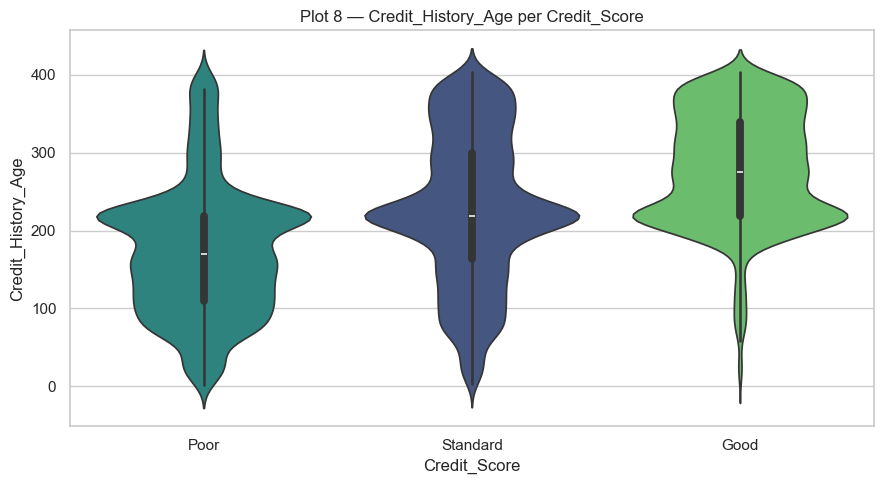

In [19]:
plt.figure(figsize=(9, 5))
sns.violinplot(x="Credit_Score", y="Credit_History_Age", data=eda, order=order,
               hue="Credit_Score", palette="viridis", legend=False)
plt.title("Plot 8 — Credit_History_Age per Credit_Score"); plt.tight_layout(); plt.show()
eda.drop(columns=["_Spending"], inplace=True)

**Insight:** Nasabah kelas `Good` memiliki distribusi `Credit_History_Age` yang lebih tinggi dan memusat (median ~22–24 tahun), sedangkan `Poor` cenderung memiliki histori lebih pendek dan lebih bervariasi — histori kredit yang panjang berkaitan erat dengan perilaku pembayaran yang konsisten dan performa kredit yang lebih baik.

## 5. Preprocessing Lanjutan — Dekomposisi Fitur Majemuk

`Payment_Behaviour` & `Type_of_Loan` menyimpan lebih dari satu informasi → kita pecah.

In [20]:
def decompose(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    # Payment_Behaviour -> Spending_Level + Payment_Size
    data["Spending_Level"] = data["Payment_Behaviour"].str.extract(r"(Low|High)_spent")
    data["Payment_Size"] = data["Payment_Behaviour"].str.extract(r"(Small|Medium|Large)_value")
    data[["Spending_Level", "Payment_Size"]] = data[["Spending_Level", "Payment_Size"]].fillna("Unknown")
    data = data.drop(columns=["Payment_Behaviour"])
    # Type_of_Loan -> jumlah jenis + jenis utama
    loans = data["Type_of_Loan"].str.replace(" and ", ",", regex=False)
    data["Num_Loan_Types"] = loans.apply(
        lambda s: 0 if str(s).strip() == "Not Specified" else len([t for t in str(s).split(",") if t.strip()]))
    data["Primary_Loan"] = loans.str.split(",").str[0].str.strip()
    data = data.drop(columns=["Type_of_Loan"])
    return data

X_train = decompose(X_train)
X_test = decompose(X_test)
print("Fitur baru:", ["Spending_Level", "Payment_Size", "Num_Loan_Types", "Primary_Loan"])
X_train[["Spending_Level", "Payment_Size", "Num_Loan_Types", "Primary_Loan"]].head()

Fitur baru: ['Spending_Level', 'Payment_Size', 'Num_Loan_Types', 'Primary_Loan']


,Spending_Level,Payment_Size,Num_Loan_Types,Primary_Loan
667,Low,Medium,3,Payday Loan
15134,High,Medium,4,Auto Loan
13076,Unknown,Unknown,4,Student Loan
13974,Low,Medium,2,Payday Loan
8294,Low,Medium,3,Payday Loan


## 6. Feature Engineering (Domain Knowledge)

Menambah **10 fitur** berbasis logika *credit scoring* — menangkap **kemampuan bayar relatif**
& **beban risiko**, yang lebih diskriminatif daripada nilai absolut.

| Fitur baru | Rumus | Makna domain |
|---|---|---|
| `Debt_to_Income` | Outstanding_Debt / pendapatan bulanan | Beban utang relatif terhadap penghasilan |
| `EMI_to_Salary` | Total_EMI / gaji bulanan | Porsi gaji untuk cicilan (DSR) |
| `Investment_Rate` | Amount_invested / gaji bulanan | Kemampuan menabung/investasi |
| `Balance_to_Salary` | Monthly_Balance / gaji bulanan | Sisa dana relatif |
| `Credit_History_Years` | Credit_History_Age / 12 | Lama histori kredit (tahun) |
| `Loan_per_Account` | Num_of_Loan / jumlah akun bank | Intensitas pinjaman per akun |
| `Delay_per_Loan` | Num_of_Delayed_Payment / jumlah pinjaman | Frekuensi telat per pinjaman |
| `Debt_per_Card` | Outstanding_Debt / jumlah kartu kredit | Utang per kartu |
| `Total_Credit_Products` | akun bank + kartu + pinjaman | Total jejak kredit (eksposur) |
| `Delay_to_History` | Num_of_Delayed_Payment / (lama histori thn) | Kronisitas telat relatif thd pengalaman kredit |

In [21]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()
    monthly_income = data["Annual_Income"] / 12 + 1
    data["Debt_to_Income"] = data["Outstanding_Debt"] / monthly_income
    data["EMI_to_Salary"] = data["Total_EMI_per_month"] / (data["Monthly_Inhand_Salary"] + 1)
    data["Investment_Rate"] = data["Amount_invested_monthly"] / (data["Monthly_Inhand_Salary"] + 1)
    data["Balance_to_Salary"] = data["Monthly_Balance"] / (data["Monthly_Inhand_Salary"] + 1)
    data["Credit_History_Years"] = data["Credit_History_Age"] / 12
    data["Loan_per_Account"] = data["Num_of_Loan"] / (data["Num_Bank_Accounts"] + 1)
    data["Delay_per_Loan"] = data["Num_of_Delayed_Payment"] / (data["Num_of_Loan"] + 1)
    data["Debt_per_Card"] = data["Outstanding_Debt"] / (data["Num_Credit_Card"] + 1)
    data["Total_Credit_Products"] = (data["Num_Bank_Accounts"] + data["Num_Credit_Card"]
                                     + data["Num_of_Loan"])
    data["Delay_to_History"] = data["Num_of_Delayed_Payment"] / (data["Credit_History_Age"] / 12 + 1)
    return data

engineered = ["Debt_to_Income", "EMI_to_Salary", "Investment_Rate", "Balance_to_Salary",
              "Credit_History_Years", "Loan_per_Account", "Delay_per_Loan", "Debt_per_Card",
              "Total_Credit_Products", "Delay_to_History"]
X_train = add_features(X_train)
X_test = add_features(X_test)

# Cap ekstrem fitur rasio di P99 (fit di train) agar tidak meledak karena pembagian
for col in engineered:
    hi = X_train[col].quantile(0.99)
    caps[col] = (X_train[col].min(), hi)
    X_train[col] = X_train[col].clip(upper=hi)
    X_test[col] = X_test[col].clip(upper=hi)
X_train[engineered].describe().round(3)

,Debt_to_Income,EMI_to_Salary,Investment_Rate,Balance_to_Salary,Credit_History_Years,Loan_per_Account,Delay_per_Loan,Debt_per_Card,Total_Credit_Products,Delay_to_History
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,0.731,0.384,0.191,0.141,18.375,0.597,4.335,213.305,14.546,1.044
std,1.028,2.221,0.735,0.092,7.905,0.526,3.929,152.105,5.704,1.207
min,0.000,0.000,0.000,0.000,0.167,0.000,0.000,0.085,1.000,0.000
25%,0.113,0.012,0.026,0.082,12.750,0.250,2.000,97.622,10.000,0.405
50%,0.333,0.025,0.045,0.115,18.250,0.500,3.000,183.691,14.000,0.695
75%,0.852,0.044,0.081,0.177,24.250,0.800,5.000,293.889,19.000,1.213
max,5.532,18.010,5.610,0.495,33.000,3.000,20.000,690.990,27.000,7.862


## 7. Encoding (sesuai karakter masing-masing fitur)

| Fitur | Karakter | Encoding |
|---|---|---|
| `Month` | ordinal waktu | Ordinal (Jan→Aug) |
| `Credit_Mix` | ordinal (Bad<Std<Good) | Ordinal |
| `Spending_Level` | ordinal (Low<High) | Ordinal |
| `Payment_Size` | ordinal (Small<Med<Large) | Ordinal |
| `Payment_of_Min_Amount` | biner | Ordinal (No=0, Yes=1) |
| `Occupation`, `Primary_Loan` | nominal | One-Hot |

Setelah encoding, semua fitur di-**StandardScaler** (wajib untuk LogReg/KNN/SVM; netral untuk tree).

In [22]:
ordinal_maps = {
    "Month": {m: i for i, m in enumerate(
        ["January", "February", "March", "April", "May", "June", "July", "August"])},
    "Credit_Mix": {"Bad": 0, "Standard": 1, "Good": 2, "Unknown": 1},
    "Spending_Level": {"Low": 0, "High": 1, "Unknown": -1},
    "Payment_Size": {"Small": 0, "Medium": 1, "Large": 2, "Unknown": -1},
    "Payment_of_Min_Amount": {"No": 0, "Yes": 1, "Unknown": 0},
}
def apply_ordinal(data):
    data = data.copy()
    for col, mp in ordinal_maps.items():
        data[col] = data[col].map(mp).fillna(-1).astype(float)
    return data

X_train_enc = apply_ordinal(X_train)
X_test_enc = apply_ordinal(X_test)

ohe_cols = ["Occupation", "Primary_Loan"]
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train_enc[ohe_cols])
ohe_names = ohe.get_feature_names_out(ohe_cols).tolist()
def merge_ohe(d):
    arr = ohe.transform(d[ohe_cols])
    return pd.concat([d.drop(columns=ohe_cols),
                      pd.DataFrame(arr, columns=ohe_names, index=d.index)], axis=1)
X_train_enc = merge_ohe(X_train_enc)
X_test_enc = merge_ohe(X_test_enc).reindex(columns=X_train_enc.columns, fill_value=0)

scaler = StandardScaler()
feature_names = X_train_enc.columns.tolist()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_enc), columns=feature_names, index=X_train_enc.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_enc), columns=feature_names, index=X_test_enc.index)

target_map = {"Poor": 0, "Standard": 1, "Good": 2}
y_train_enc = y_train.map(target_map).astype(int)
y_test_enc = y_test.map(target_map).astype(int)
print("Jumlah fitur final:", X_train_scaled.shape[1], "| Target:", target_map)

Jumlah fitur final: 58 | Target: {'Poor': 0, 'Standard': 1, 'Good': 2}


## 8. Modeling — 10 Model Tanpa Tuning

Kita melatih **10 algoritma** tanpa tuning untuk membuat *leaderboard* awal (Macro-F1).
**Penanganan imbalance: SMOTE-Tomek terbatas** — hanya kelas minoritas (`Good`) yang
di-*oversample* sampai setara kelas terbesar-kedua (`Poor`), lalu *Tomek links* membersihkan
pasangan antar-kelas yang tumpang tindih. Resampling **hanya pada data training**; validation
& test **tidak pernah** di-resample (anti-leakage).

Leaderboard memakai **hold-out validation** (20% dari train; SMOTE-Tomek di-fit hanya pada porsi
training-nya) untuk ranking cepat. Top-3 nanti dievaluasi ulang dengan Stratified 5-Fold.

In [23]:
def smt_strategy(y):
    """Naikkan HANYA kelas minoritas sampai = jumlah kelas terbesar-kedua (mis. Good -> level Poor)."""
    c = Counter(y)
    ordered = sorted(c, key=lambda k: c[k], reverse=True)   # [majority, middle, minority]
    target = c[ordered[1]]                                  # jumlah kelas terbesar-kedua
    minority = ordered[-1]
    return {minority: max(target, c[minority])}

def make_smt():
    return SMOTETomek(smote=SMOTE(sampling_strategy=smt_strategy, random_state=RANDOM_STATE),
                      random_state=RANDOM_STATE)

def build_models():
    return {
        "LogisticRegression": LogisticRegression(max_iter=2000, n_jobs=-1, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=25, n_jobs=-1),
        "SVM": SVC(kernel="rbf", random_state=RANDOM_STATE),
        "DecisionTree": DecisionTreeClassifier(max_depth=12, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
        "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(objective="multi:softprob", eval_metric="mlogloss",
                                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
        "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    }

# Hold-out validation; SMOTE-Tomek di-fit HANYA pada porsi training hold-out (val tidak disentuh)
X_tr_b, X_val_b, y_tr_b, y_val_b = train_test_split(
    X_train_scaled, y_train_enc, test_size=0.2, stratify=y_train_enc, random_state=RANDOM_STATE)
X_res_b, y_res_b = make_smt().fit_resample(X_tr_b, y_tr_b)
print("Distribusi train hold-out  :", dict(sorted(Counter(y_tr_b).items())))
print("Distribusi setelah SMOTE-Tk:", dict(sorted(Counter(y_res_b).items())))

leaderboard = []
for name, model in build_models().items():
    t0 = time.time()
    model.fit(X_res_b, y_res_b)
    pred = np.asarray(model.predict(X_val_b)).ravel().astype(int)
    f1m = f1_score(y_val_b, pred, average="macro")
    leaderboard.append({"Model": name, "Val_Macro_F1": f1m, "Fit_sec": round(time.time() - t0, 1)})
    print(f"{name:<20} Macro-F1 = {f1m:.4f}  ({time.time() - t0:.1f}s)")

lb = pd.DataFrame(leaderboard).sort_values("Val_Macro_F1", ascending=False).reset_index(drop=True)

Distribusi train hold-out  : {0: 4651, 1: 8501, 2: 2848}
Distribusi setelah SMOTE-Tk: {0: 3911, 1: 7555, 2: 4367}


LogisticRegression   Macro-F1 = 0.6267  (0.4s)


KNN                  Macro-F1 = 0.5894  (0.2s)


SVM                  Macro-F1 = 0.6501  (42.1s)


DecisionTree         Macro-F1 = 0.6462  (0.3s)


...

AdaBoost             Macro-F1 = 0.6181  (7.5s)


GradientBoosting     Macro-F1 = 0.6599  (25.4s)


XGBoost              Macro-F1 = 0.6798  (2.3s)


LightGBM             Macro-F1 = 0.6804  (0.7s)


CatBoost             Macro-F1 = 0.6797  (14.9s)


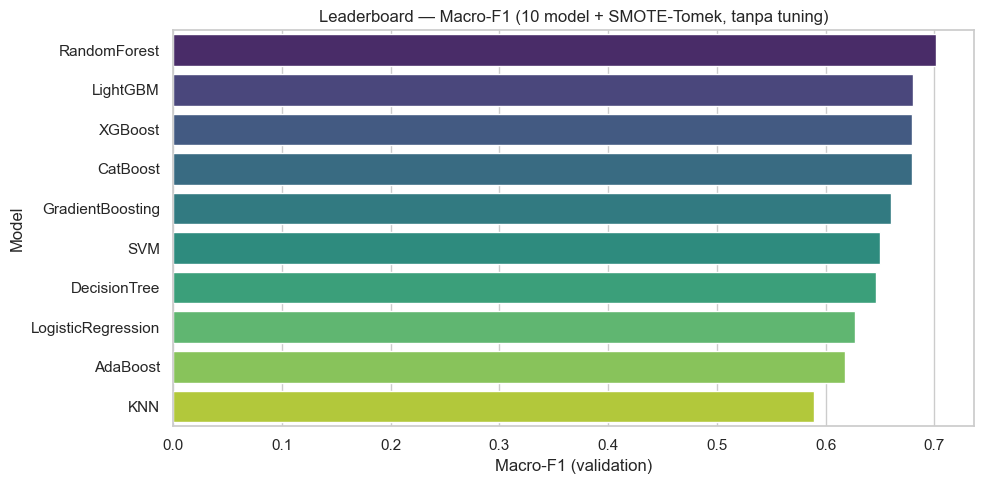

,Model,Val_Macro_F1,Fit_sec
0,RandomForest,0.701303,2.2
1,LightGBM,0.680398,0.7
2,XGBoost,0.679759,2.3
3,CatBoost,0.679663,14.9
4,GradientBoosting,0.659897,25.4
5,SVM,0.650145,42.1
6,DecisionTree,0.646246,0.3
7,LogisticRegression,0.626725,0.4
8,AdaBoost,0.618139,7.5
9,KNN,0.589442,0.2


In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=lb, y="Model", x="Val_Macro_F1", hue="Model", palette="viridis", legend=False)
plt.title("Leaderboard — Macro-F1 (10 model + SMOTE-Tomek, tanpa tuning)")
plt.xlabel("Macro-F1 (validation)"); plt.tight_layout(); plt.show()
lb

### 8.1 Pilih Top-3 Model

In [25]:
top3 = lb["Model"].head(3).tolist()
print("Top-3 (by Macro-F1):", top3)

Top-3 (by Macro-F1): ['RandomForest', 'LightGBM', 'XGBoost']


## 9. Hyperparameter Tuning — GridSearchCV + Stratified 5-Fold

Top-3 di-tuning dengan `GridSearchCV` (Stratified **5-fold**, scoring `f1_macro`). Tiap kandidat
dibungkus pipeline **`SMOTE-Tomek → model`** sehingga resampling terjadi **per-fold, hanya pada
fold training** (fold validasi tidak pernah di-resample). Grid dibuat ringkas namun sesuai
karakter tiap model (prefix `clf__` karena berada di dalam pipeline).

In [26]:
def tuning_config(name):
    """Kembalikan (estimator, param_grid) — grid pakai prefix 'clf__' (di dalam pipeline)."""
    cfg = {
        "LogisticRegression": (LogisticRegression(max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE),
                               {"clf__C": [0.1, 1.0, 10.0]}),
        "KNN": (KNeighborsClassifier(n_jobs=-1),
                {"clf__n_neighbors": [15, 25, 35], "clf__weights": ["uniform", "distance"]}),
        "SVM": (SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
                {"clf__C": [1.0, 10.0]}),
        "DecisionTree": (DecisionTreeClassifier(random_state=RANDOM_STATE),
                         {"clf__max_depth": [8, 12, 16], "clf__min_samples_leaf": [10, 20]}),
        "RandomForest": (RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=RANDOM_STATE),
                         {"clf__max_depth": [24, None], "clf__min_samples_leaf": [2, 4],
                          "clf__max_features": ["sqrt"]}),
        "AdaBoost": (AdaBoostClassifier(random_state=RANDOM_STATE),
                     {"clf__n_estimators": [200, 400], "clf__learning_rate": [0.5, 1.0]}),
        "GradientBoosting": (GradientBoostingClassifier(random_state=RANDOM_STATE),
                             {"clf__n_estimators": [200], "clf__max_depth": [3, 5],
                              "clf__learning_rate": [0.05, 0.1]}),
        "XGBoost": (XGBClassifier(objective="multi:softprob", eval_metric="mlogloss",
                                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
                    {"clf__n_estimators": [400], "clf__max_depth": [6, 8],
                     "clf__learning_rate": [0.05], "clf__subsample": [0.8, 1.0]}),
        "LightGBM": (LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
                     {"clf__n_estimators": [600], "clf__num_leaves": [63, 127],
                      "clf__learning_rate": [0.05]}),
        "CatBoost": (CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
                     {"clf__iterations": [500], "clf__depth": [6, 8], "clf__learning_rate": [0.05]}),
    }
    return cfg[name]

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tuned_models, tuning_results = {}, []
for name in top3:
    est, grid = tuning_config(name)
    pipe = ImbPipeline([("smt", make_smt()), ("clf", est)])
    gs_jobs = 1 if name == "CatBoost" else -1  # CatBoost paralel internal -> hindari oversubscription
    gs = GridSearchCV(pipe, grid, cv=skf5, scoring="f1_macro", n_jobs=gs_jobs, verbose=0)
    gs.fit(X_train_scaled, y_train_enc)
    tuned_models[name] = gs.best_estimator_   # ImbPipeline ter-refit di seluruh train
    tuning_results.append({"Model": name, "Best_CV_Macro_F1": gs.best_score_, "Best_Params": gs.best_params_})
    print(f"{name:<18} CV Macro-F1 = {gs.best_score_:.4f} | {gs.best_params_}")

tuning_df = pd.DataFrame(tuning_results).sort_values("Best_CV_Macro_F1", ascending=False).reset_index(drop=True)
tuning_df[["Model", "Best_CV_Macro_F1"]]

RandomForest       CV Macro-F1 = 0.7017 | {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2}


LightGBM           CV Macro-F1 = 0.7079 | {'clf__learning_rate': 0.05, 'clf__n_estimators': 600, 'clf__num_leaves': 127}


XGBoost            CV Macro-F1 = 0.7043 | {'clf__learning_rate': 0.05, 'clf__max_depth': 8, 'clf__n_estimators': 400, 'clf__subsample': 0.8}


,Model,Best_CV_Macro_F1
0,LightGBM,0.707894
1,XGBoost,0.704295
2,RandomForest,0.701720


### 9.1 Evaluasi Top-3 Tuned di Test Set & Pilih Model Terbaik

In [27]:
def safe_proba(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    return None

test_rows = []
for name, mdl in tuned_models.items():
    pred = np.asarray(mdl.predict(X_test_scaled)).ravel().astype(int)
    proba = safe_proba(mdl, X_test_scaled)
    auc = roc_auc_score(y_test_enc, proba, multi_class="ovr") if proba is not None else np.nan
    test_rows.append({"Model": name,
                      "Accuracy": accuracy_score(y_test_enc, pred),
                      "Macro_F1": f1_score(y_test_enc, pred, average="macro"),
                      "ROC_AUC": auc})
test_df = pd.DataFrame(test_rows).sort_values("Macro_F1", ascending=False).reset_index(drop=True)
best_name = test_df.iloc[0]["Model"]
best_model = tuned_models[best_name]
print(">>> MODEL TERBAIK:", best_name)
test_df.round(4)

>>> MODEL TERBAIK: LightGBM


,Model,Accuracy,Macro_F1,ROC_AUC
0,LightGBM,0.7404,0.7217,0.8846
1,XGBoost,0.7350,0.7165,0.8815
2,RandomForest,0.7300,0.7141,0.8765


### 9.2 Laporan Lengkap TIAP Model Top-3 di Test Set

Tiap model Top-3 dievaluasi **individual** di test set: classification report per-kelas
(precision/recall/F1) + confusion matrix masing-masing.

===== RandomForest (tuned) =====
              precision    recall  f1-score   support

        Poor      0.741     0.710     0.725      1454
    Standard      0.787     0.738     0.762      2656
        Good      0.589     0.738     0.655       890

    accuracy                          0.730      5000
   macro avg      0.706     0.729     0.714      5000
weighted avg      0.738     0.730     0.732      5000

Accuracy 0.7300 | Macro-F1 0.7141 | ROC-AUC 0.8765



===== LightGBM (tuned) =====
              precision    recall  f1-score   support

        Poor      0.744     0.729     0.737      1454
    Standard      0.767     0.773     0.770      2656
        Good      0.655     0.662     0.658       890

    accuracy                          0.740      5000
   macro avg      0.722     0.721     0.722      5000
weighted avg      0.740     0.740     0.740      5000

Accuracy 0.7404 | Macro-F1 0.7217 | ROC-AUC 0.8846



===== XGBoost (tuned) =====
              precision    recall  f1-score   support

        Poor      0.748     0.719     0.734      1454
    Standard      0.767     0.764     0.765      2656
        Good      0.628     0.675     0.651       890

    accuracy                          0.735      5000
   macro avg      0.714     0.719     0.716      5000
weighted avg      0.737     0.735     0.736      5000

Accuracy 0.7350 | Macro-F1 0.7165 | ROC-AUC 0.8815



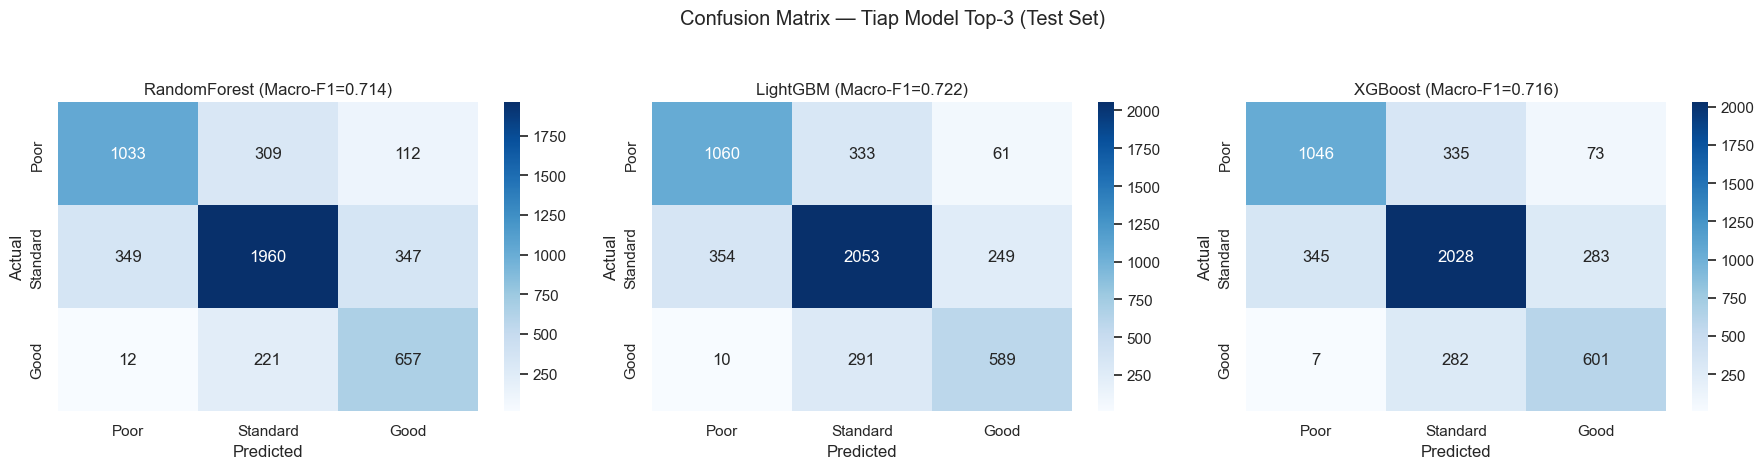

In [28]:
names = ["Poor", "Standard", "Good"]
fig, axes = plt.subplots(1, len(top3), figsize=(6 * len(top3), 4.5))
axes = np.atleast_1d(axes)
for ax, mname in zip(axes, top3):
    mdl = tuned_models[mname]
    pred = np.asarray(mdl.predict(X_test_scaled)).ravel().astype(int)
    acc = accuracy_score(y_test_enc, pred)
    f1m = f1_score(y_test_enc, pred, average="macro")
    proba = safe_proba(mdl, X_test_scaled)
    auc = roc_auc_score(y_test_enc, proba, multi_class="ovr") if proba is not None else float("nan")
    print(f"===== {mname} (tuned) =====")
    print(classification_report(y_test_enc, pred, target_names=names, digits=3))
    print(f"Accuracy {acc:.4f} | Macro-F1 {f1m:.4f} | ROC-AUC {auc:.4f}\n")
    cm = confusion_matrix(y_test_enc, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(f"{mname} (Macro-F1={f1m:.3f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrix — Tiap Model Top-3 (Test Set)", y=1.04)
plt.tight_layout(); plt.show()

## 11. Feature Importance

Stacking adalah gabungan beberapa model sehingga tidak punya satu set importance tunggal.
Sebagai interpretasi, kita tampilkan importance dari **model tunggal terbaik** (proxy) —
diakses dari step `clf` di dalam pipeline-nya.

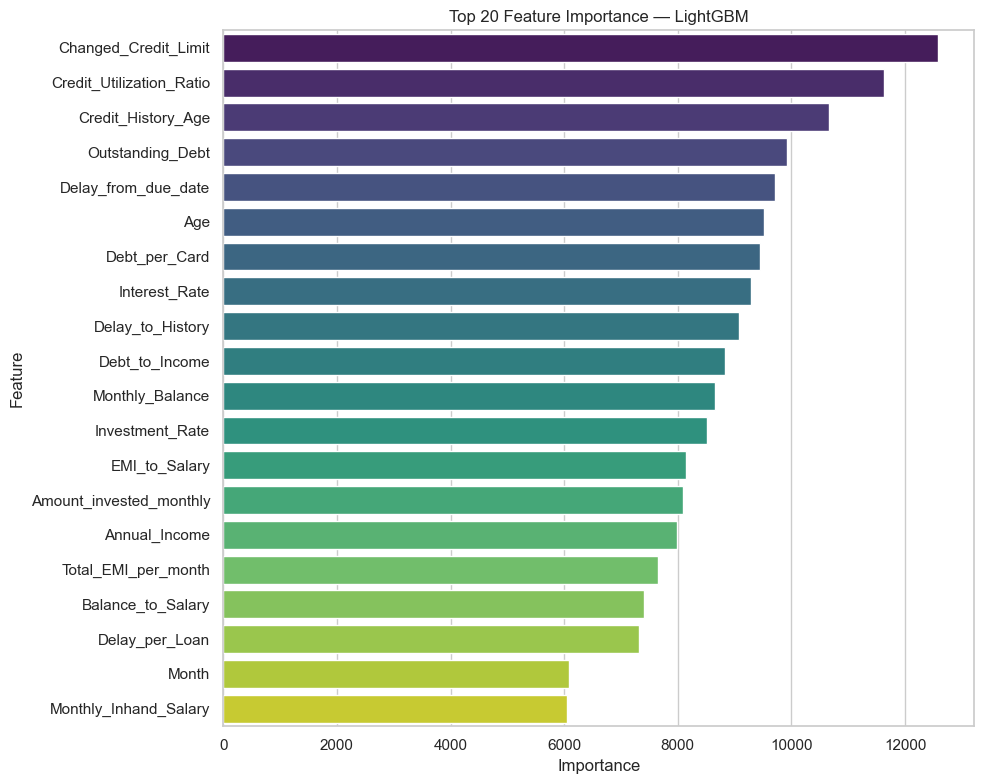

                 Feature  Importance
    Changed_Credit_Limit       12585
Credit_Utilization_Ratio       11623
      Credit_History_Age       10660
        Outstanding_Debt        9925
     Delay_from_due_date        9706
                     Age        9514
           Debt_per_Card        9454
           Interest_Rate        9292
        Delay_to_History        9070
          Debt_to_Income        8830
         Monthly_Balance        8647
         Investment_Rate        8516
           EMI_to_Salary        8151
 Amount_invested_monthly        8083
           Annual_Income        7985
     Total_EMI_per_month        7647
       Balance_to_Salary        7401
          Delay_per_Loan        7309
                   Month        6093
   Monthly_Inhand_Salary        6047


In [32]:
best_single_clf = tuned_models[best_name].named_steps["clf"]
imp, title = None, None
if hasattr(best_single_clf, "feature_importances_"):
    imp = best_single_clf.feature_importances_
    title = f"Top 20 Feature Importance — {best_name}"
elif hasattr(best_single_clf, "coef_"):
    imp = np.abs(best_single_clf.coef_).mean(axis=0)
    title = f"Top 20 Feature Importance (|coef|) — {best_name}"

if imp is not None:
    fi = (pd.DataFrame({"Feature": feature_names, "Importance": imp})
          .sort_values("Importance", ascending=False).head(20))
    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
    plt.title(title); plt.tight_layout(); plt.show()
    print(fi.to_string(index=False))
else:
    print(f"{best_name} tidak menyediakan feature importance bawaan.")

**Interpretasi:** Fitur paling berpengaruh umumnya indikator perilaku & riwayat kredit
(`Credit_Mix`, `Outstanding_Debt`, `Interest_Rate`, `Credit_History_Age`, `Delay_from_due_date`,
`Payment_of_Min_Amount`) serta fitur rasio hasil engineering (`Debt_to_Income`). Konsisten
dengan logika domain: **perilaku pembayaran** lebih menentukan skor kredit daripada demografi.

## 12. Kesimpulan

- **Fitur:** indikator finansial & perilaku kredit + **10 fitur rasio domain**; kolom identitas
  (`Unnamed: 0`, `ID`, `Customer_ID`, `Name`, `SSN`) di-drop.
- **Preprocessing:** split lebih dulu → core cleaning per-baris → imputasi median/Unknown →
  outlier capping (IQR + P99) → dekomposisi fitur majemuk → feature engineering → encoding
  (ordinal + one-hot) + scaling. **Semua statistik di-fit hanya di train** (anti-leakage).
- **Imbalance:** **SMOTE-Tomek terbatas** (minoritas `Good` → level `Poor`) di dalam pipeline,
  sehingga validation/test tidak pernah di-resample.
- **Model & eksperimen:** 10 model dibandingkan → Top-3 di-tuning (GridSearchCV, Stratified
  5-Fold) → digabung via **stacking (simplex blending, bobot dicari grid search di OOF)**.
- **Metrik:** Macro-F1 (utama) + Accuracy + per-class recall + ROC-AUC (OvR).

Pendekatan terbaik & metriknya dirangkum pada tabel Bagian 10.1. (Penyimpanan artefak `.pkl`
sengaja belum dilakukan di tahap eksplorasi ini — akan diformalkan di pipeline OOP `.py`.)